# Credit Risk Scoring & Loan Approval System

## 💼 Business Understanding

### Key business questions

- Which borrowers are likely to default?
- How can borrowers be grouped into risk levels?
- What approval threshold should be used?
- What financial tradeoffs exist between risky approvals and rejected customers?
- Which factors contribute most to default risk?

### Main objectives

- Predict borrower default probability
- Build a credit risk scoring system
- Create risk-based borrower segmentation
- Develop loan approval decision logic
- Evaluate business and financial tradeoffs
- Improve interpretability using SHAP
- Assess fairness and bias
- Deploy an interactive Streamlit dashboard

### Problem type

- Binary classification problem

### Target variable

- `0` → No serious financial distress
- `1` → Serious financial distress within two years

### Modeling goal

Predict the probability of borrower default risk.

In [1]:
# Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [2]:
# Load training dataset
df = pd.read_csv(
    "/kaggle/input/competitions/GiveMeSomeCredit/cs-training.csv"
)

df.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [3]:
# Check dataset shape
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")

Rows: 150000
Columns: 12


In [4]:
# View column names
df.columns

Index(['Unnamed: 0', 'SeriousDlqin2yrs',
       'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [5]:
# Display dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

In [6]:
# Remove unnecessary column
df = df.drop(columns="Unnamed: 0")

df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


### Insights

- The dataset contains 150,000 borrower records and 12 columns.
- Most variables are numerical and related to credit usage, delinquency history, debt ratio, and borrowing behavior.
- The target variable is `SeriousDlqin2yrs`, which indicates whether a borrower experienced serious financial distress within two years.
- `MonthlyIncome` and `NumberOfDependents` contain missing values that will require preprocessing later.
- `Unnamed: 0` appears to be an index-like column and may not provide predictive value.

In [7]:
# Check target distribution
target_counts = df["SeriousDlqin2yrs"].value_counts()
target_percentages = (
    df["SeriousDlqin2yrs"]
    .value_counts(normalize=True) * 100
)

target_summary = pd.DataFrame({
    "Count": target_counts,
    "Percentage": target_percentages.round(2)
})

target_summary

,Count,Percentage
SeriousDlqin2yrs,,
0,139974,93.32
1,10026,6.68


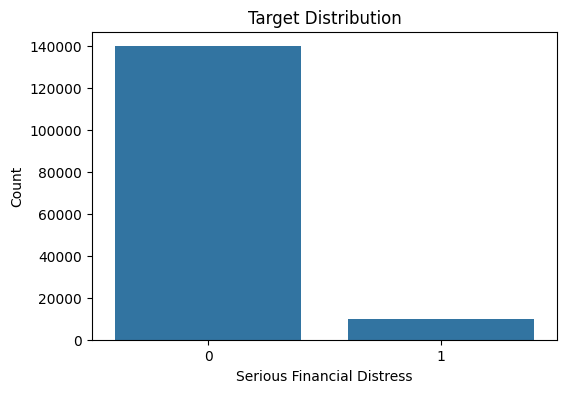

In [8]:
# Visualize target distribution
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="SeriousDlqin2yrs"
)

plt.title("Target Distribution")
plt.xlabel("Serious Financial Distress")
plt.ylabel("Count")

plt.show()

### Insights

- The dataset is highly imbalanced.
- About 93.32% of borrowers did not experience serious financial distress.
- Only 6.68% belong to the default/high-risk class.
- This imbalance makes accuracy less reliable as a standalone evaluation metric.
- Later stages will focus more on recall, precision, probability calibration, and threshold tuning.

## 📊 Exploratory Data Analysis

In [9]:
# Check missing values
missing_values = df.isnull().sum()

missing_summary = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (
        missing_values / len(df) * 100
    ).round(2)
})

missing_summary.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62
SeriousDlqin2yrs,0,0.00
age,0,0.00
RevolvingUtilizationOfUnsecuredLines,0,0.00
DebtRatio,0,0.00
NumberOfTime30-59DaysPastDueNotWorse,0,0.00
NumberOfOpenCreditLinesAndLoans,0,0.00
NumberOfTimes90DaysLate,0,0.00
NumberRealEstateLoansOrLines,0,0.00


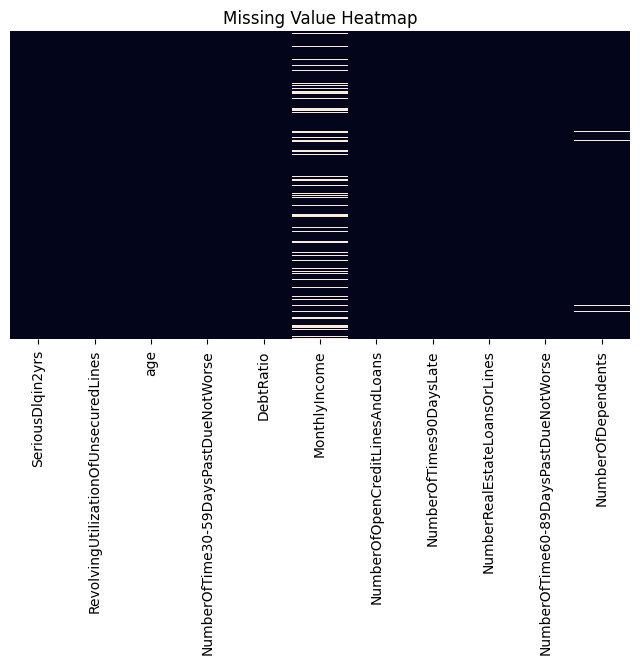

In [10]:
# Visualize missing values
plt.figure(figsize=(8, 4))

sns.heatmap(
    df.isnull(),
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")

plt.show()

### Insights

- `MonthlyIncome` has a significant amount of missing data, with nearly 20% of records missing income information.
- `NumberOfDependents` contains a smaller percentage of missing values.
- Most other financial and delinquency-related variables are complete.
- The missingness pattern appears concentrated rather than randomly spread across many variables.
- Since income is an important credit risk factor, handling missing income values carefully will be important during preprocessing and modeling.

In [11]:
# Display statistical summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
SeriousDlqin2yrs,150000.0,0.066840,0.249746,0.0,0.000000,0.000000,0.000000,1.0
RevolvingUtilizationOfUnsecuredLines,150000.0,6.048438,249.755371,0.0,0.029867,0.154181,0.559046,50708.0
age,150000.0,52.295207,14.771866,0.0,41.000000,52.000000,63.000000,109.0
NumberOfTime30-59DaysPastDueNotWorse,150000.0,0.421033,4.192781,0.0,0.000000,0.000000,0.000000,98.0
DebtRatio,150000.0,353.005076,2037.818523,0.0,0.175074,0.366508,0.868254,329664.0
MonthlyIncome,120269.0,6670.221237,14384.674215,0.0,3400.000000,5400.000000,8249.000000,3008750.0
NumberOfOpenCreditLinesAndLoans,150000.0,8.452760,5.145951,0.0,5.000000,8.000000,11.000000,58.0
NumberOfTimes90DaysLate,150000.0,0.265973,4.169304,0.0,0.000000,0.000000,0.000000,98.0
NumberRealEstateLoansOrLines,150000.0,1.018240,1.129771,0.0,0.000000,1.000000,2.000000,54.0
NumberOfTime60-89DaysPastDueNotWorse,150000.0,0.240387,4.155179,0.0,0.000000,0.000000,0.000000,98.0


In [12]:
#Check borrowers with age equal to 0
df[df["age"] == 0]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
65695,0,1.0,0,1,0.436927,6000.0,6,0,2,0,2.0


In [13]:
# Check extreme revolving utilization values
df[
    df["RevolvingUtilizationOfUnsecuredLines"] > 5
][
    ["RevolvingUtilizationOfUnsecuredLines"]
].describe()

,RevolvingUtilizationOfUnsecuredLines
count,254.000000
mean,3381.930768
std,5051.880235
min,5.148736
25%,760.500000
50%,1899.000000
75%,3871.750000
max,50708.000000


In [14]:
# Check extreme debt ratio values
df[
    df["DebtRatio"] > 5
][
    ["DebtRatio"]
].describe()

,DebtRatio
count,29646.000000
mean,1784.589721
std,4296.240265
min,5.021978
25%,305.000000
50%,1291.000000
75%,2466.000000
max,329664.000000


In [15]:
# Check unusual delinquency values
df[
    (
        df["NumberOfTime30-59DaysPastDueNotWorse"] == 98
    ) |
    (
        df["NumberOfTime60-89DaysPastDueNotWorse"] == 98
    ) |
    (
        df["NumberOfTimes90DaysLate"] == 98
    )
]

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1733,1,1.0,27,98,0.0,2700.0,0,98,0,98,0.0
2286,0,1.0,22,98,0.0,NaN,0,98,0,98,0.0
3884,0,1.0,38,98,12.0,NaN,0,98,0,98,0.0
4417,0,1.0,21,98,0.0,0.0,0,98,0,98,0.0
4705,0,1.0,21,98,0.0,2000.0,0,98,0,98,0.0
...,...,...,...,...,...,...,...,...,...,...,...
147774,1,1.0,68,98,255.0,NaN,0,98,0,98,0.0
149153,1,1.0,24,98,54.0,NaN,0,98,0,98,0.0
149239,0,1.0,26,98,0.0,2000.0,0,98,0,98,0.0
149439,1,1.0,34,98,9.0,NaN,0,98,0,98,0.0


### Data Quality Observations

- Several variables contain unrealistic or highly suspicious values.
- One borrower has an age value of `0`, which is likely a data quality issue.
- `RevolvingUtilizationOfUnsecuredLines` contains extremely large values far beyond normal utilization ranges.
- `DebtRatio` also contains unusually large observations, suggesting possible outliers or scaling inconsistencies.
- The delinquency-related variables contain repeated values of `98`, which appears abnormal and may represent placeholder or corrupted values rather than actual delinquency counts.
- These findings suggest that outlier handling and data quality checks will play an important role before modeling.

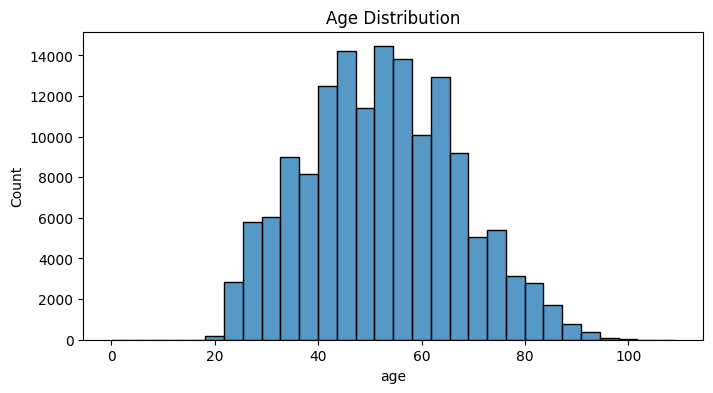

In [16]:
# Visualize age distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    data=df,
    x="age",
    bins=30
)

plt.title("Age Distribution")

plt.show()

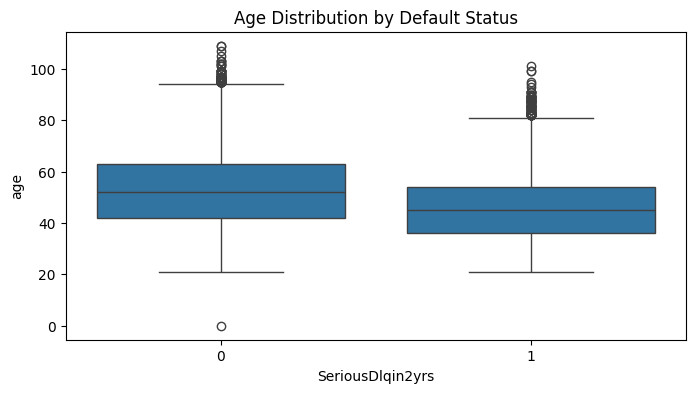

In [17]:
# Compare age by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="age"
)

plt.title("Age Distribution by Default Status")

plt.show()

### Age Analysis

Most borrowers fall between approximately 30 and 70 years old, with the distribution concentrated around middle-aged individuals. Borrowers who experienced serious financial distress appear slightly younger on average compared to non-default borrowers.

A small number of unusually high age values and one borrower with an age value of `0` appear as potential data quality issues. Overall, age may provide useful predictive signal for default risk and should be explored further during feature analysis.

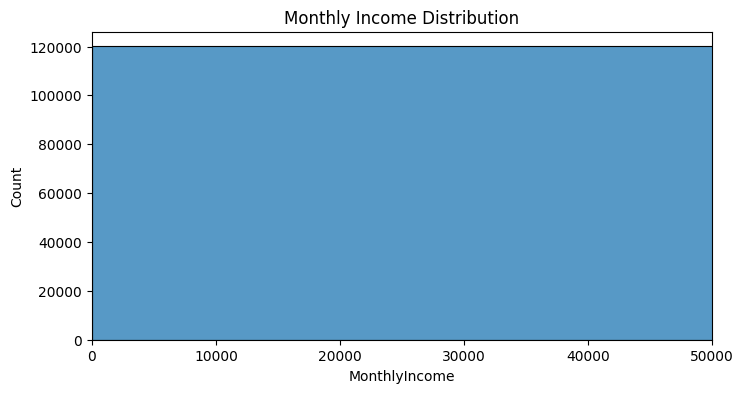

In [18]:
# Visualize monthly income distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    df["MonthlyIncome"],
    bins=50
)

plt.title("Monthly Income Distribution")

plt.xlim(0, 50000)

plt.show()

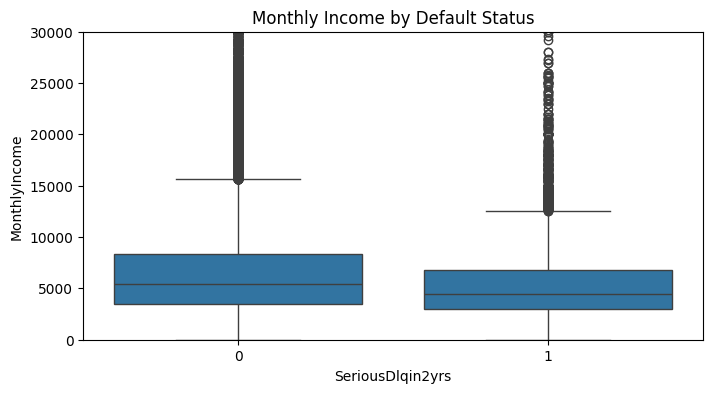

In [19]:
# Compare monthly income by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="MonthlyIncome"
)

plt.title("Monthly Income by Default Status")

plt.ylim(0, 30000)

plt.show()

### Income Analysis

Monthly income is heavily right-skewed, with a small number of borrowers showing extremely large income values. Most borrowers fall within the lower income ranges, while high-income observations extend far beyond the typical distribution.

Borrowers who experienced serious financial distress appear to have lower median income levels compared to non-default borrowers, although both groups contain substantial outliers.

### Visualization Notes

Axis limits were intentionally applied to improve readability. Without limiting the scale, extreme income outliers compress most observations into a very small visible range, making the distribution difficult to interpret visually.

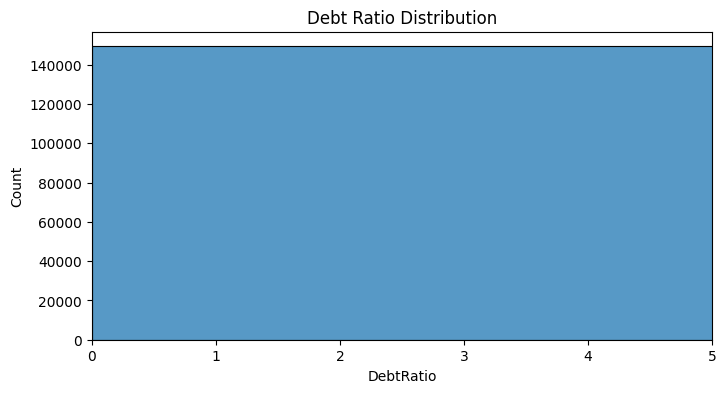

In [20]:
# Visualize debt ratio distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    df["DebtRatio"],
    bins=50
)

plt.title("Debt Ratio Distribution")

plt.xlim(0, 5)

plt.show()

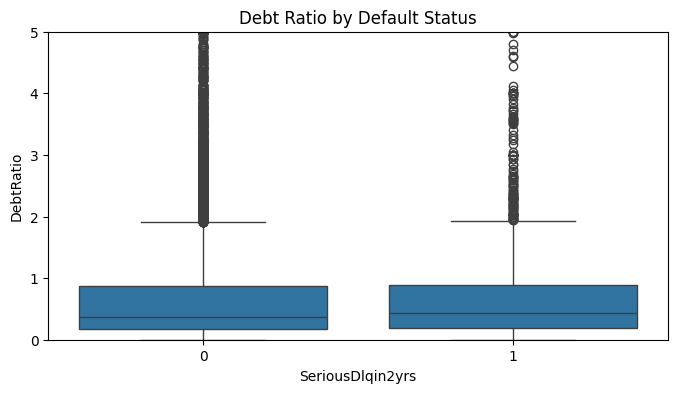

In [21]:
# Compare debt ratio by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="DebtRatio"
)

plt.title("Debt Ratio by Default Status")

plt.ylim(0, 5)

plt.show()

### Debt Ratio Analysis

Debt ratio values are highly right-skewed, with many extreme observations extending far beyond typical borrowing behavior. Most borrowers appear concentrated at lower debt ratio levels, while a smaller group shows unusually large values.

Borrowers who experienced serious financial distress generally show slightly higher debt ratios compared to non-default borrowers. The default group also appears to contain more extreme high-ratio observations.

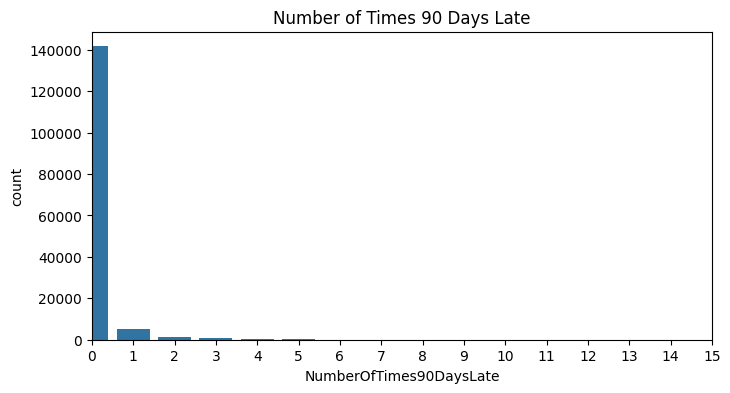

In [22]:
# Visualize 90-days-late distribution
plt.figure(figsize=(8, 4))

sns.countplot(
    data=df,
    x="NumberOfTimes90DaysLate"
)

plt.title("Number of Times 90 Days Late")

plt.xlim(0, 15)

plt.show()

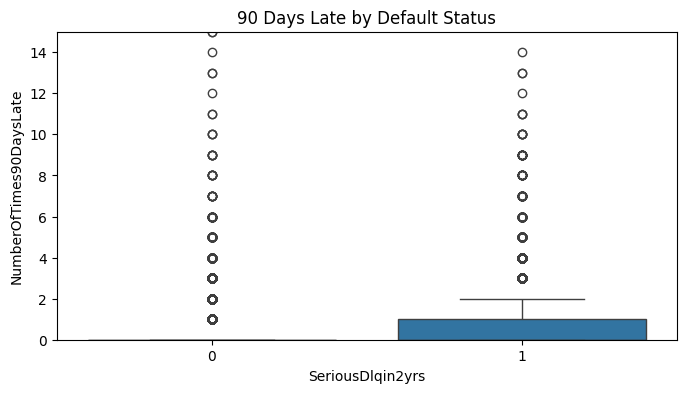

In [23]:
# Compare 90-days-late counts by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="NumberOfTimes90DaysLate"
)

plt.title("90 Days Late by Default Status")

plt.ylim(0, 15)

plt.show()

### Delinquency Analysis

Most borrowers have no history of being 90 days late, while progressively fewer borrowers appear as delinquency counts increase. The distribution is highly concentrated around zero, which is expected in consumer credit datasets.

Borrowers who experienced serious financial distress generally show higher delinquency counts compared to non-default borrowers. The default group displays a noticeably wider spread of late-payment behavior.

This suggests that severe delinquency history may be an important predictor of future default risk.

In [24]:
# Calculate default rate by 90-days-late count
late_payment_risk = (
    df.groupby("NumberOfTimes90DaysLate")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

late_payment_risk.columns = [
    "LatePayments90Days",
    "DefaultRate"
]

late_payment_risk.head(15)

,LatePayments90Days,DefaultRate
0,0,0.046265
1,1,0.336639
2,2,0.499035
3,3,0.577211
4,4,0.670103
5,5,0.633588
6,6,0.600000
7,7,0.815789
8,8,0.714286
9,9,0.736842


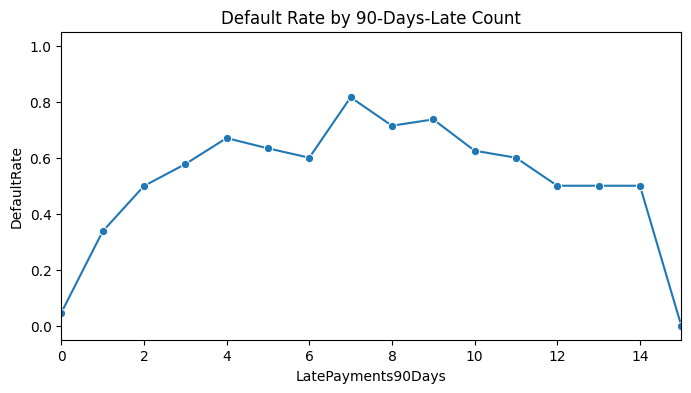

In [25]:
# Visualize default rate by 90-days-late count
plt.figure(figsize=(8, 4))

sns.lineplot(
    data=late_payment_risk,
    x="LatePayments90Days",
    y="DefaultRate",
    marker="o"
)

plt.title("Default Rate by 90-Days-Late Count")

plt.xlim(0, 15)

plt.show()

### Risk Trend Analysis

Default risk increases sharply as the number of 90-days-late payments rises. Borrowers with no severe delinquency history show a relatively low default rate of around 4.6%, while borrowers with multiple severe late payments exhibit substantially higher risk levels.

The relationship is especially strong during the early increases in delinquency count, suggesting that repayment history is likely one of the most important predictors of financial distress in this dataset.

Some fluctuations appear at higher delinquency counts because those groups contain fewer borrowers, making the default rates less stable.

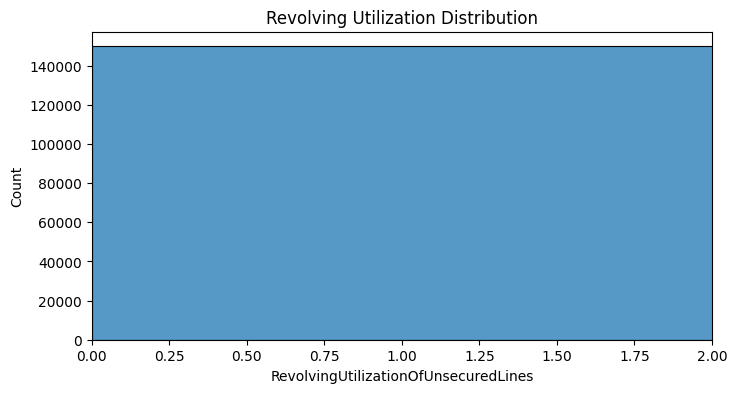

In [26]:
# Visualize revolving utilization distribution
plt.figure(figsize=(8, 4))

sns.histplot(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=50
)

plt.title("Revolving Utilization Distribution")

plt.xlim(0, 2)

plt.show()

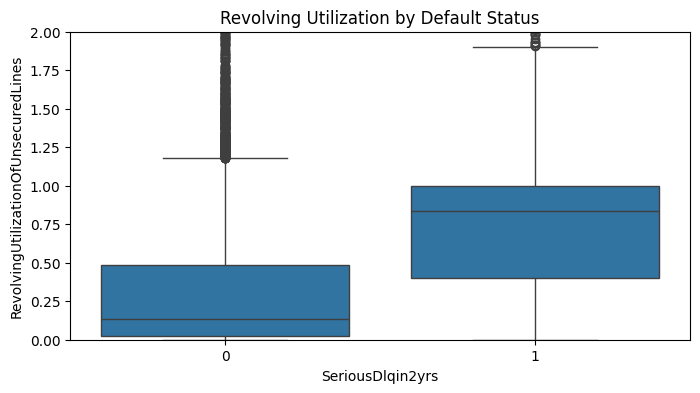

In [27]:
# Compare revolving utilization by default status
plt.figure(figsize=(8, 4))

sns.boxplot(
    data=df,
    x="SeriousDlqin2yrs",
    y="RevolvingUtilizationOfUnsecuredLines"
)

plt.title("Revolving Utilization by Default Status")

plt.ylim(0, 2)

plt.show()

### Credit Utilization Analysis

Revolving credit utilization shows a strong relationship with default risk. Borrowers who experienced serious financial distress generally have substantially higher utilization levels compared to non-default borrowers.

The non-default group is concentrated at relatively low utilization levels, while the default group shows a much higher median utilization and wider spread. This suggests that heavy reliance on unsecured revolving credit may be an important indicator of financial stress.

In [28]:
# Calculate feature correlations with target
correlation_with_target = (
    df.corr(numeric_only=True)
    ["SeriousDlqin2yrs"]
    .sort_values(ascending=False)
)

correlation_with_target

SeriousDlqin2yrs                        1.000000
NumberOfTime30-59DaysPastDueNotWorse    0.125587
NumberOfTimes90DaysLate                 0.117175
NumberOfTime60-89DaysPastDueNotWorse    0.102261
NumberOfDependents                      0.046048
RevolvingUtilizationOfUnsecuredLines   -0.001802
NumberRealEstateLoansOrLines           -0.007038
DebtRatio                              -0.007602
MonthlyIncome                          -0.019746
NumberOfOpenCreditLinesAndLoans        -0.029669
age                                    -0.115386
Name: SeriousDlqin2yrs, dtype: float64

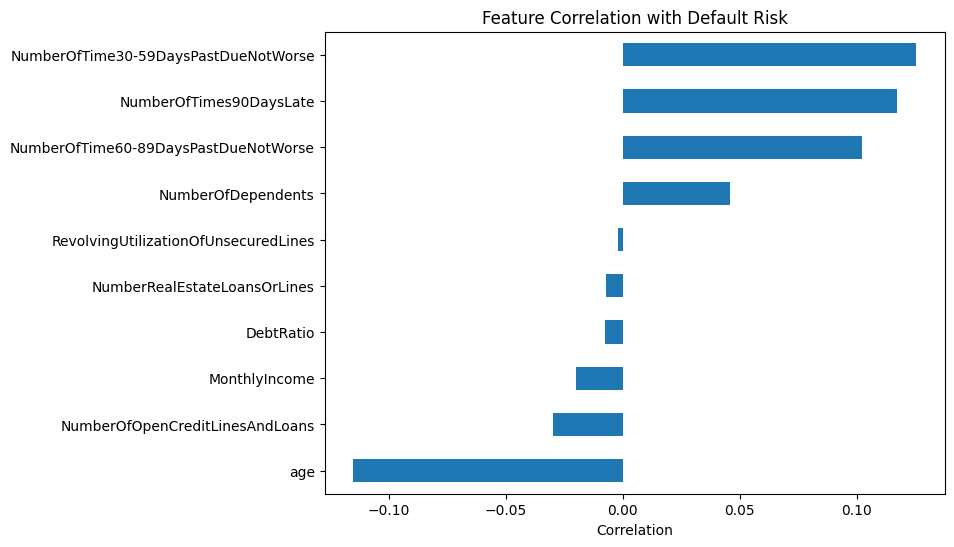

In [29]:
# Visualize correlations with target
plt.figure(figsize=(8, 6))

correlation_with_target.drop(
    "SeriousDlqin2yrs"
).sort_values().plot(
    kind="barh"
)

plt.title("Feature Correlation with Default Risk")

plt.xlabel("Correlation")

plt.show()

### Correlation Analysis

Delinquency-related variables show the strongest positive relationship with default risk. Borrowers with more frequent late-payment history are generally more likely to experience serious financial distress.

`NumberOfTime30-59DaysPastDueNotWorse`, `NumberOfTimes90DaysLate`, and `NumberOfTime60-89DaysPastDueNotWorse` appear to be the most influential risk indicators based on linear correlation strength.

Age shows a moderate negative relationship with default risk, suggesting that younger borrowers may be more likely to default. Monthly income and number of open credit lines also show slight negative relationships with financial distress.

Some variables, such as `DebtRatio` and `RevolvingUtilizationOfUnsecuredLines`, show surprisingly weak linear correlations despite earlier visual patterns. This may indicate the presence of non-linear relationships, extreme outliers, or skewed distributions that are not fully captured by simple correlation analysis.

In [30]:
# Create age groups
df["AgeGroup"] = pd.cut(
    df["age"],
    bins=[20, 30, 40, 50, 60, 70, 110],
    labels=[
        "20-30",
        "31-40",
        "41-50",
        "51-60",
        "61-70",
        "71+"
    ]
)

df["AgeGroup"].value_counts()

AgeGroup
41-50    35037
51-60    34806
61-70    27424
31-40    24339
71+      17636
20-30    10757
Name: count, dtype: int64

In [31]:
# Calculate default rate by age group
age_risk = (
    df.groupby("AgeGroup")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

age_risk.columns = [
    "AgeGroup",
    "DefaultRate"
]

age_risk

,AgeGroup,DefaultRate
0,20-30,0.115646
1,31-40,0.098196
2,41-50,0.082570
3,51-60,0.061742
4,61-70,0.034714
5,71+,0.022567


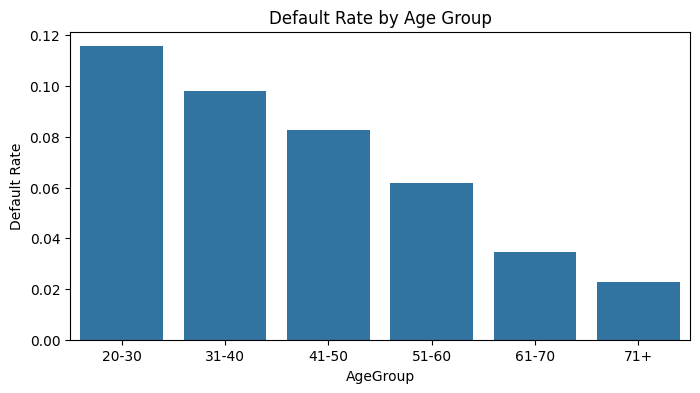

In [32]:
# Visualize default rate by age group
plt.figure(figsize=(8, 4))

sns.barplot(
    data=age_risk,
    x="AgeGroup",
    y="DefaultRate"
)

plt.title("Default Rate by Age Group")

plt.ylabel("Default Rate")

plt.show()

### Age Risk Segmentation

Default risk decreases steadily as borrower age increases. The youngest borrowers between 20 and 30 years old show the highest default rate at approximately 11.6%, while borrowers aged 71 and above show the lowest default risk.

This trend suggests that younger borrowers may face greater financial instability or repayment challenges compared to older borrowers. Older borrowers generally appear to exhibit more stable repayment behavior.

The relationship between age and default risk is consistent with the earlier correlation analysis, where age showed a negative relationship with financial distress risk.

In [33]:
# Create income groups
df["IncomeGroup"] = pd.qcut(
    df["MonthlyIncome"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

df["IncomeGroup"].value_counts()

IncomeGroup
Very Low     25084
High         24084
Medium       24057
Very High    24020
Low          23024
Name: count, dtype: int64

In [34]:
# Calculate default rate by income group
income_risk = (
    df.groupby("IncomeGroup")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

income_risk.columns = [
    "IncomeGroup",
    "DefaultRate"
]

income_risk

,IncomeGroup,DefaultRate
0,Very Low,0.090775
1,Low,0.085954
2,Medium,0.070125
3,High,0.055306
4,Very High,0.045046


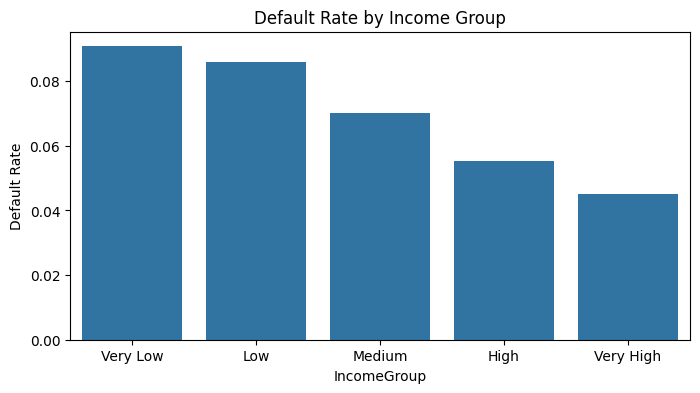

In [35]:
# Visualize default rate by income group
plt.figure(figsize=(8, 4))

sns.barplot(
    data=income_risk,
    x="IncomeGroup",
    y="DefaultRate"
)

plt.title("Default Rate by Income Group")

plt.ylabel("Default Rate")

plt.show()

### Income Risk Segmentation

Default risk declines consistently as borrower income increases. Borrowers in the very low income group show the highest default rates, while borrowers in the very high income group exhibit the lowest risk levels.

This pattern suggests that income level is an important indicator of repayment capacity and financial stability. Higher-income borrowers may have greater ability to absorb financial shocks and manage debt obligations.

The relationship also aligns with earlier findings where defaulted borrowers generally showed lower income levels compared to non-default borrowers.

In [36]:
# Create utilization groups
df["UtilizationGroup"] = pd.cut(
    df["RevolvingUtilizationOfUnsecuredLines"],
    bins=[0, 0.3, 0.6, 0.9, 1.2, 2],
    labels=[
        "Very Low",
        "Low",
        "Moderate",
        "High",
        "Very High"
    ]
)

df["UtilizationGroup"].value_counts()

UtilizationGroup
Very Low     82004
Low          21887
High         19031
Moderate     15162
Very High      667
Name: count, dtype: int64

In [37]:
# Calculate default rate by utilization group
utilization_risk = (
    df.groupby("UtilizationGroup")
    ["SeriousDlqin2yrs"]
    .mean()
    .reset_index()
)

utilization_risk.columns = [
    "UtilizationGroup",
    "DefaultRate"
]

utilization_risk

,UtilizationGroup,DefaultRate
0,Very Low,0.021231
1,Low,0.066798
2,Moderate,0.133030
3,High,0.216541
4,Very High,0.466267


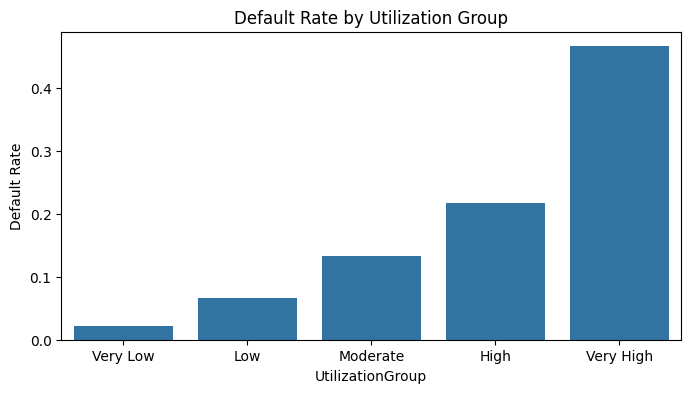

In [38]:
# Visualize default rate by utilization group
plt.figure(figsize=(8, 4))

sns.barplot(
    data=utilization_risk,
    x="UtilizationGroup",
    y="DefaultRate"
)

plt.title("Default Rate by Utilization Group")

plt.ylabel("Default Rate")

plt.show()

### Credit Utilization Risk Segmentation

Default risk increases sharply as revolving credit utilization rises. Borrowers in the very low utilization group show relatively low default rates, while borrowers in the very high utilization group exhibit substantially elevated risk levels.

The increase in default risk appears gradual across utilization bands, suggesting a strong relationship between heavy credit usage and financial distress. Borrowers with utilization levels above 1.2 show particularly high default rates, approaching nearly 47%.

This pattern indicates that revolving credit utilization may be one of the most important predictors of borrower risk in the dataset and could play a major role in the future credit scoring system.

## 📌 Key EDA Findings

### Main Findings

- The dataset contains significant class imbalance, with most borrowers belonging to the non-default class.
- `MonthlyIncome` and `NumberOfDependents` contain missing values that will require preprocessing.
- Several variables contain suspicious or unrealistic values, including extreme utilization ratios, unusually large debt ratios, and repeated delinquency values of `98`.
- Delinquency-related variables show the strongest positive relationship with default risk.
- Younger borrowers generally exhibit higher default rates compared to older borrowers.
- Lower-income borrowers show substantially higher financial distress risk than higher-income borrowers.
- Revolving credit utilization demonstrates one of the clearest relationships with default probability, with risk increasing sharply at higher utilization levels.

### Business Interpretation

The exploratory analysis suggests that borrower repayment behavior, credit utilization, and financial capacity are important drivers of default risk. Several strong risk patterns identified during EDA may later contribute significantly to model performance and credit scoring decisions.

The findings also highlight the importance of careful preprocessing and outlier handling before model development.